In [2]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import List
import random
import math
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
try:
    from timm.utils import ModelEmaV3
except ModuleNotFoundError:
    import copy

    class ModelEmaV3:
        def __init__(self, model, decay=0.9999):
            self.module = copy.deepcopy(model).eval()
            self.decay = decay
            for param in self.module.parameters():
                param.requires_grad_(False)

        @torch.no_grad()
        def update(self, model):
            ema_state = self.module.state_dict()
            model_state = model.state_dict()
            for key, value in ema_state.items():
                if value.dtype.is_floating_point:
                    value.mul_(self.decay).add_(model_state[key].detach(), alpha=1 - self.decay)
                else:
                    value.copy_(model_state[key])

        def state_dict(self):
            return self.module.state_dict()

        def load_state_dict(self, state_dict):
            self.module.load_state_dict(state_dict)
from tqdm import tqdm #pip install tqdm
import matplotlib.pyplot as plt #pip install matplotlib
import torch.optim as optim
import numpy as np
import os

In [3]:
class SinusoidalEmbeddings(nn.Module):
    def __init__(self, time_steps:int, embed_dim: int):
        super().__init__()
        position = torch.arange(time_steps).unsqueeze(dim=1).float()
        div = torch.exp(torch.arange(0, embed_dim, 2).float() * -(math.log(10000) / embed_dim))
        embeddings = torch.zeros(time_steps, embed_dim, requires_grad=False)
        embeddings[:, 0::2] = torch.sin(position * div)
        embeddings[:, 1::2] = torch.cos(position * div)
        self.register_buffer('embeddings', embeddings)

    def forward(self, x, t):
        t = torch.as_tensor(t, dtype=torch.long, device=x.device)
        embeds = self.embeddings[t]
        return embeds[:, :, None, None]

In [4]:
# Residual block
class ResBlock(nn.Module):
    def __init__(self, C: int, num_groups: int, dropout_prob: float):
        super().__init__()
        self.relu = nn.ReLU(inplace= True)
        self.gnorm1 = nn.GroupNorm(num_groups = num_groups, num_channels=C )
        self.gnorm2 = nn.GroupNorm(num_groups = num_groups, num_channels=C )
        self.conv1 = nn.Conv2d(C, C, kernel_size= 3, padding=1)
        self.conv2 = nn.Conv2d(C, C, kernel_size= 3, padding=1)
        self.dropout = nn.Dropout(p = dropout_prob, inplace= True)

    def forward(self, x, embeddings):
        x = x + embeddings[:, :x.shape[1], :, :]
        r = self.conv1(self.relu(self.gnorm1(x)))
        r = self.dropout(r)
        r = self.conv2(self.relu(self.gnorm2(r)))
        return r+x

In [5]:
class Attention(nn.Module):
    def __init__(self, C:int, num_heads:int, dropout_prob: float):
        super().__init__()
        self.proj1 = nn.Linear(C, C*3)
        self.proj2 = nn.Linear(C,C)
        self.num_heads = num_heads
        self.dropout_prob = dropout_prob

    def forward(self, x):
        b, c, h, w = x.shape
        x = x.permute(0, 2, 3, 1).reshape(b, h * w, c)
        x = self.proj1(x)
        x = x.reshape(b, h * w, 3, self.num_heads, c // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = x[0], x[1], x[2]
        x = F.scaled_dot_product_attention(q, k, v, is_causal=False, dropout_p=self.dropout_prob)
        x = x.permute(0, 2, 1, 3).reshape(b, h, w, c)
        x = self.proj2(x)
        return x.permute(0, 3, 1, 2)

In [6]:
class UnetLayer(nn.Module):
    def __init__(self,
                 upscale: bool,
                 attention: bool,
                 num_groups: int,
                 dropout_prob: float,
                 num_heads: int,
                 C: int):
        super().__init__()
        self.ResBlock1 = ResBlock(C, num_groups, dropout_prob)
        self.ResBlock2 = ResBlock(C, num_groups, dropout_prob)
        if upscale:
            self.conv = nn.ConvTranspose2d(C, C//2, kernel_size=4, stride = 2,padding=1)
        else:
            self.conv = nn.Conv2d(C, C*2, kernel_size=3, stride=2,padding=1)
        if attention:
            self.attention_layer = Attention(C, num_heads, dropout_prob)

    def forward(self, x, embeddings):
        x = self.ResBlock1(x, embeddings)
        if hasattr(self, 'attention_layer'):
            x = self.attention_layer(x)
        x = self.ResBlock2(x, embeddings)
        return self.conv(x), x

In [7]:
class UNET(nn.Module):
    def __init__(self,
                 Channels: List = [64, 128, 256, 512, 512, 384],
                 Attentions: List = [False, True, False, False, False, True],
                 Upscales: List = [False, False, False, True, True, True],
                 num_groups: int = 32,
                 dropout_prob: float = 0.1,
                 num_heads: int = 8,
                 input_channels: int = 1,
                 output_channels: int = 1,
                 time_steps: int = 1000):
        super().__init__()
        self.num_layers = len(Channels)
        self.shallow_conv = nn.Conv2d(input_channels, Channels[0], kernel_size=3, padding=1)
        out_channels = (Channels[-1]//2) + Channels[0]
        self.late_conv = nn.Conv2d(out_channels, out_channels//2, kernel_size=3, padding=1)
        self.output_conv = nn.Conv2d(out_channels//2, output_channels, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)
        self.embeddings = SinusoidalEmbeddings(time_steps=time_steps, embed_dim=max(Channels))
        for i in range(self.num_layers):
            layer = UnetLayer(
                upscale=Upscales[i],
                attention=Attentions[i],
                num_groups=num_groups,
                dropout_prob=dropout_prob,
                C=Channels[i],
                num_heads=num_heads
            )
            setattr(self, f'Layer{i+1}', layer)

    def forward(self, x, t):
        x = self.shallow_conv(x)
        residuals = []
        for i in range(self.num_layers//2):
            layer = getattr(self, f'Layer{i+1}')
            embeddings = self.embeddings(x, t)
            x, r = layer(x, embeddings)
            residuals.append(r)
        for i in range(self.num_layers//2, self.num_layers):
            layer = getattr(self, f'Layer{i+1}')
            embeddings = self.embeddings(x, t)
            x = torch.concat((layer(x, embeddings)[0], residuals[self.num_layers-i-1]), dim = 1)
        return self.output_conv(self.relu(self.late_conv(x)))


In [8]:
class DDPM_Scheduler(nn.Module):
    def __init__(self, num_time_steps: int=1000):
        super().__init__()
        beta = torch.linspace(1e-4, 0.02, num_time_steps, requires_grad=False)
        self.register_buffer('beta', beta)
        alpha = 1 - self.beta
        self.register_buffer('alpha', torch.cumprod(alpha, dim=0).requires_grad_(False))

    def forward(self, t):
        return self.beta[t], self.alpha[t]


In [9]:
def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)

In [10]:
def train(batch_size: int=64,
          num_time_steps: int=1000,
          num_epochs: int=15,
          seed: int=-1,
          ema_decay: float=0.999,
          lr=2e-4,
          checkpoint_path: str=None):
    set_seed(random.randint(0, 2**32-1)) if seed == -1 else set_seed(seed)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    train_dataset = datasets.MNIST(root='./data', train=True, download = True, transform=transforms.ToTensor())
    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True, drop_last=True, num_workers=4)

    scheduler = DDPM_Scheduler(num_time_steps=num_time_steps).to(device)
    model = UNET(time_steps=num_time_steps).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    ema = ModelEmaV3(model, decay=ema_decay)
    if checkpoint_path is not None:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['weights'])
        ema.load_state_dict(checkpoint['ema'])
        optimizer.load_state_dict(checkpoint['optimizer'])
    criterion = nn.MSELoss(reduction='mean')

    for i in range(num_epochs):
        total_loss = 0
        for bidx, (x, _) in enumerate(tqdm(train_loader, desc=f"Epoch {i+1}/{num_epochs}")):
            x = x.to(device)
            x = F.pad(x, (2,2,2,2))
            t = torch.randint(0, num_time_steps, (batch_size, ), device=device)
            e = torch.randn_like(x, requires_grad=False)
            a = scheduler.alpha[t].view(batch_size,1,1,1)
            x = (torch.sqrt(a)*x) + (torch.sqrt(1-a)*e)
            output = model(x, t)
            optimizer.zero_grad()
            loss = criterion(output, e)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            ema.update(model)
        print(f'Epoch {i+1} | Loss {total_loss / (60000/batch_size):.5f}')

    checkpoint = {
        'weights': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'ema': ema.state_dict()
    }
    os.makedirs('checkpoints', exist_ok=True)
    torch.save(checkpoint, 'checkpoints/ddpm_checkpoint')

In [11]:
def display_reverse(images: List):
    fig, axes = plt.subplots(1, 10, figsize=(10,1))
    for i, ax in enumerate(axes.flat):
        x = images[i].squeeze(0)
        x = x.permute(1, 2, 0)
        x = x.detach().cpu().numpy()
        ax.imshow(x)
        ax.axis('off')
    plt.show()

def inference(checkpoint_path: str=None,
              num_time_steps: int=1000,
              ema_decay: float=0.999, ):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model = UNET(time_steps=num_time_steps).to(device)
    model.load_state_dict(checkpoint['weights'])
    ema = ModelEmaV3(model, decay=ema_decay)
    ema.load_state_dict(checkpoint['ema'])
    scheduler = DDPM_Scheduler(num_time_steps=num_time_steps).to(device)
    times = [0,15,50,100,200,300,400,550,700,999]
    images = []

    with torch.no_grad():
        model = ema.module.eval()
        for i in range(10):
            z = torch.randn(1, 1, 32, 32, device=device)
            for t in reversed(range(1, num_time_steps)):
                t_tensor = torch.tensor([t], dtype=torch.long, device=device)
                temp = (scheduler.beta[t_tensor]/( (torch.sqrt(1-scheduler.alpha[t_tensor]))*(torch.sqrt(1-scheduler.beta[t_tensor])) ))
                z = (1/(torch.sqrt(1-scheduler.beta[t_tensor])))*z - (temp*model(z,t_tensor))
                if t in times:
                    images.append(z.detach().cpu())
                e = torch.randn(1, 1, 32, 32, device=device)
                z = z + (e*torch.sqrt(scheduler.beta[t_tensor]))
            temp = scheduler.beta[0]/( (torch.sqrt(1-scheduler.alpha[0]))*(torch.sqrt(1-scheduler.beta[0])) )
            x = (1/(torch.sqrt(1-scheduler.beta[0])))*z - (temp*model(z, torch.tensor([0], dtype=torch.long, device=device)))

            images.append(x.detach().cpu())
            x = x.squeeze(0).permute(1, 2, 0).detach().cpu()
            x = x.numpy()
            plt.imshow(x)
            plt.show()
            display_reverse(images)
            images = []

In [12]:
def ddim_inference(checkpoint_path: str=None,
                   num_time_steps: int=1000,
                   ddim_steps: int=50,
                   eta: float=0.0,
                   ema_decay: float=0.999, ):
    """DDIM sampling.

    Dùng lại đúng model epsilon-predictor đã train với DDPM. Lưu ý trong
    DDPM_Scheduler, `scheduler.alpha` chính là alpha_bar (cumprod của 1-beta).

    - ddim_steps: số bước lấy mẫu (vd 50). Càng ít càng nhanh.
    - eta: 0.0 -> deterministic DDIM; 1.0 -> tương đương DDPM stochastic.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model = UNET(time_steps=num_time_steps).to(device)
    model.load_state_dict(checkpoint['weights'])
    ema = ModelEmaV3(model, decay=ema_decay)
    ema.load_state_dict(checkpoint['ema'])
    scheduler = DDPM_Scheduler(num_time_steps=num_time_steps).to(device)

    # Chọn tập con timestep, đi từ cao -> thấp: [..., 999 -> 0]
    step_indices = torch.linspace(0, num_time_steps - 1, ddim_steps, device=device).long()
    step_indices = torch.flip(step_indices, dims=[0])

    # 10 thời điểm để hiển thị tiến trình khử nhiễu
    snap_at = set(torch.linspace(0, ddim_steps - 1, 10).long().tolist())
    images = []

    with torch.no_grad():
        model = ema.module.eval()
        for img_idx in range(10):
            z = torch.randn(1, 1, 32, 32, device=device)
            for i in range(ddim_steps):
                t = int(step_indices[i].item())
                t_tensor = torch.tensor([t], dtype=torch.long, device=device)
                alpha_bar_t = scheduler.alpha[t]

                eps = model(z, t_tensor)
                # Ước lượng x0 từ x_t và noise dự đoán
                x0 = (z - torch.sqrt(1 - alpha_bar_t) * eps) / torch.sqrt(alpha_bar_t)

                # alpha_bar của bước kế tiếp (bước cuối coi như alpha_bar=1 -> ra x0)
                if i < ddim_steps - 1:
                    t_prev = int(step_indices[i + 1].item())
                    alpha_bar_prev = scheduler.alpha[t_prev]
                else:
                    alpha_bar_prev = torch.ones_like(alpha_bar_t)

                # Phương sai stochastic (eta=0 -> sigma=0 -> tất định)
                sigma = eta * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar_t)) \
                            * torch.sqrt(1 - alpha_bar_t / alpha_bar_prev)
                noise = torch.randn_like(z) if eta > 0 else torch.zeros_like(z)

                dir_xt = torch.sqrt(torch.clamp(1 - alpha_bar_prev - sigma**2, min=0.0)) * eps
                z = torch.sqrt(alpha_bar_prev) * x0 + dir_xt + sigma * noise

                if i in snap_at:
                    images.append(z.detach().cpu())

            x = z.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
            plt.imshow(x)
            plt.show()
            display_reverse(images)
            images = []

DDPM Sampling:


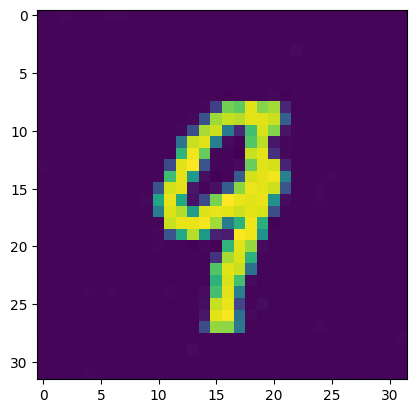

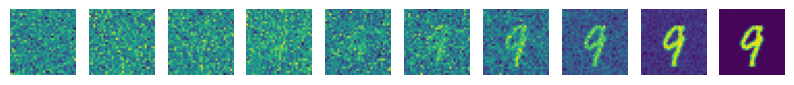

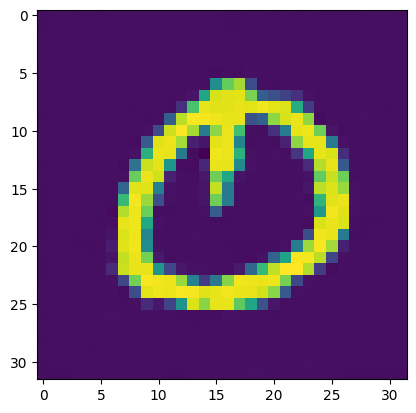

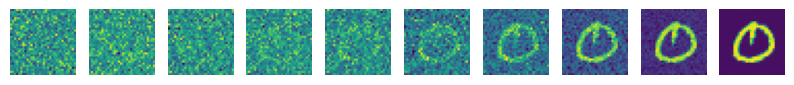

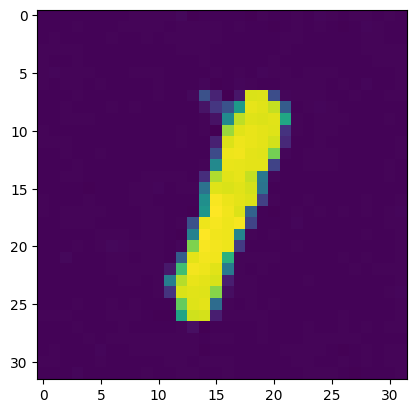

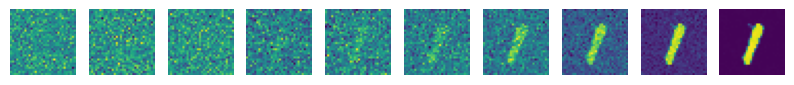

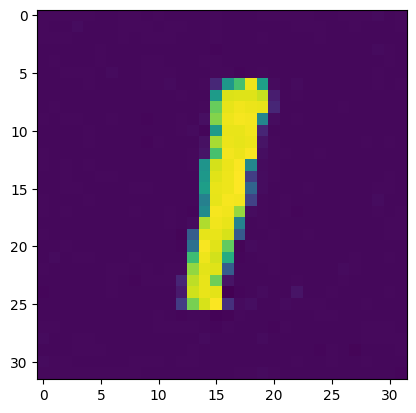

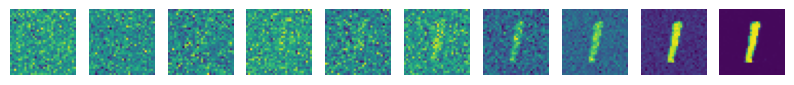

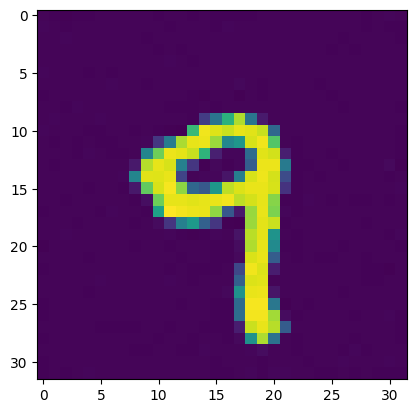

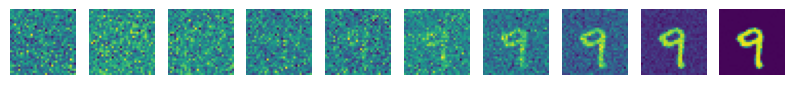

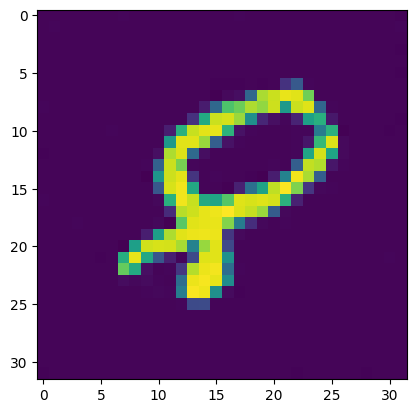

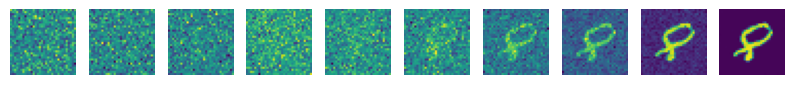

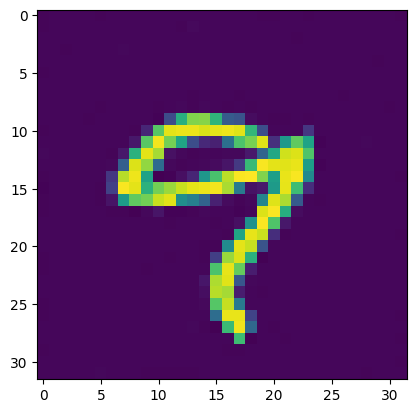

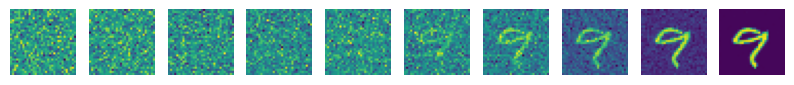

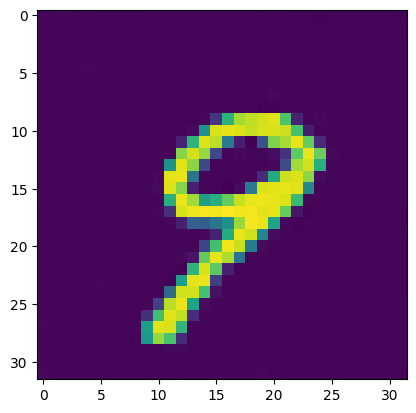

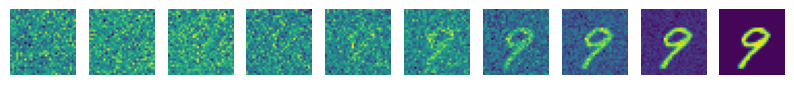

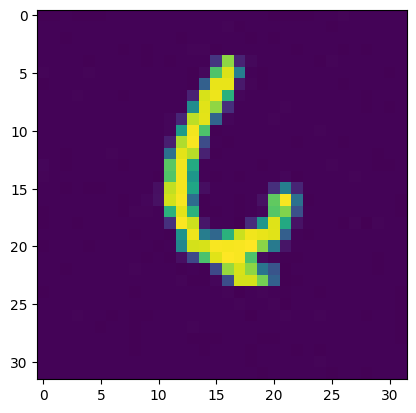

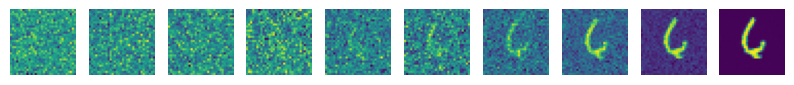

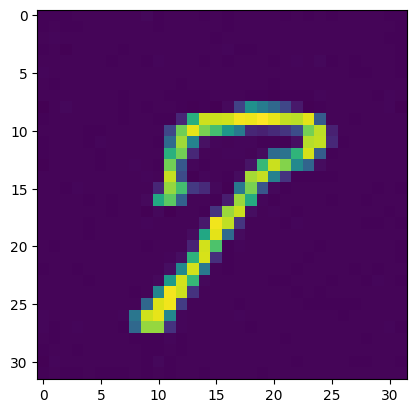

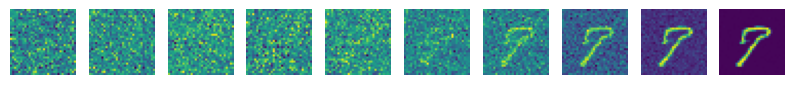

DDIM Sampling:


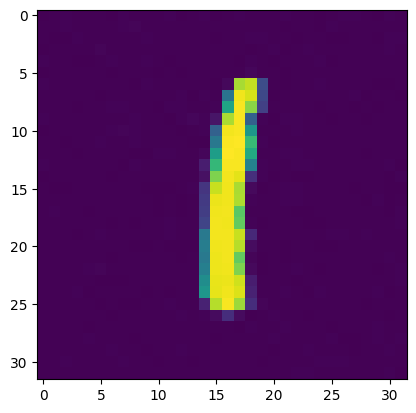

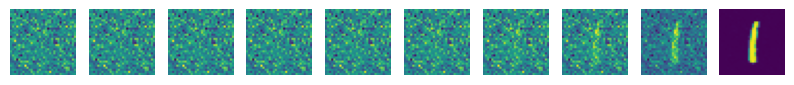

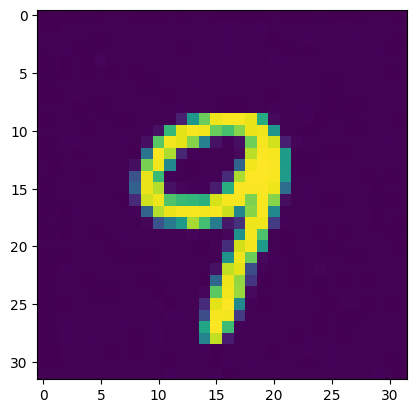

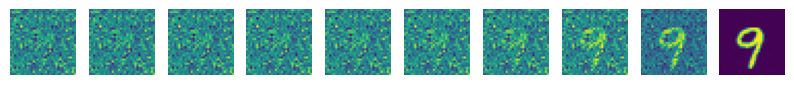

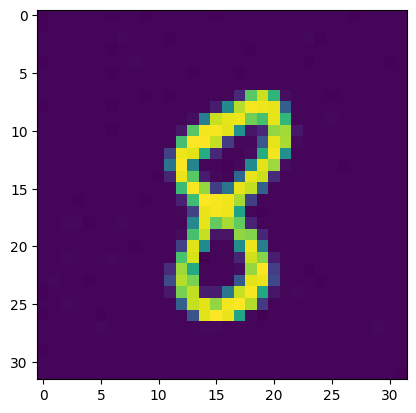

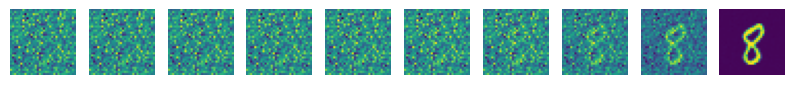

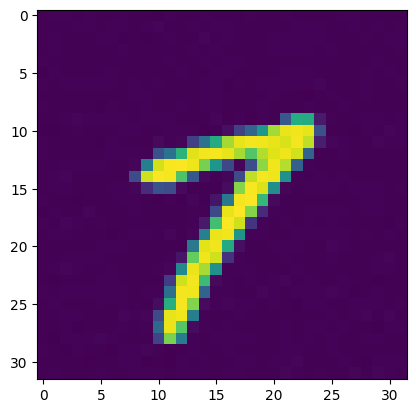

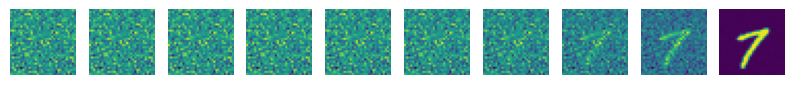

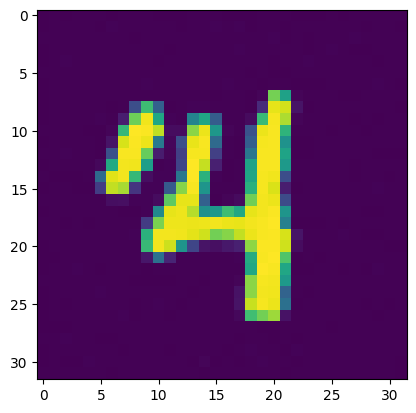

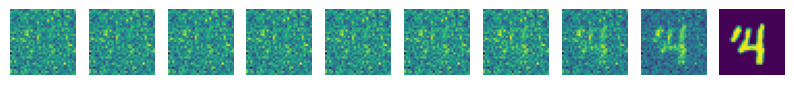

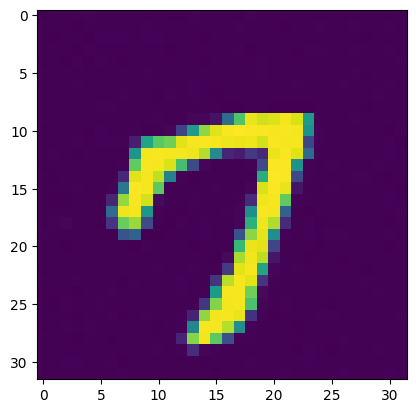

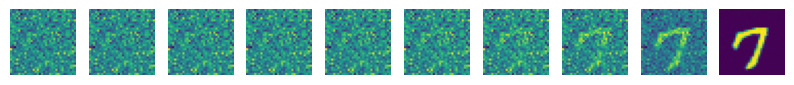

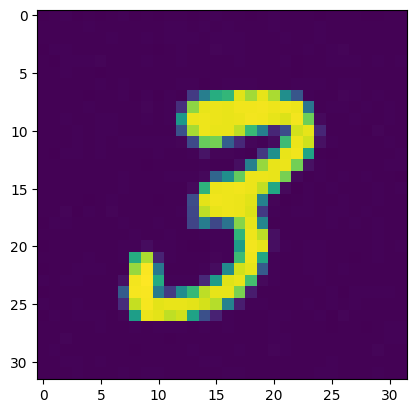

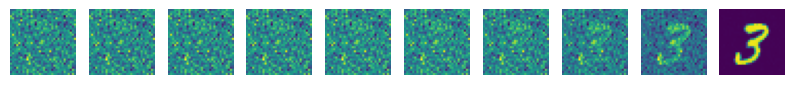

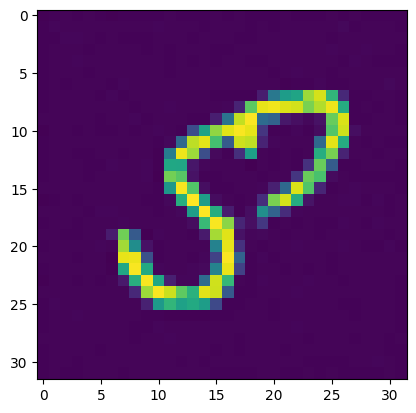

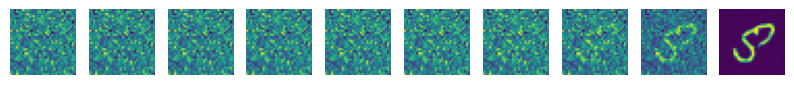

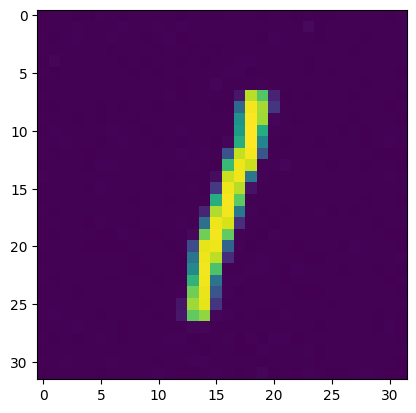

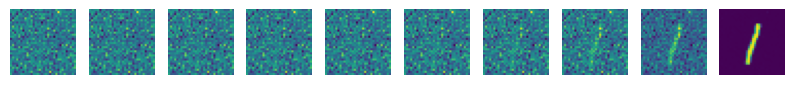

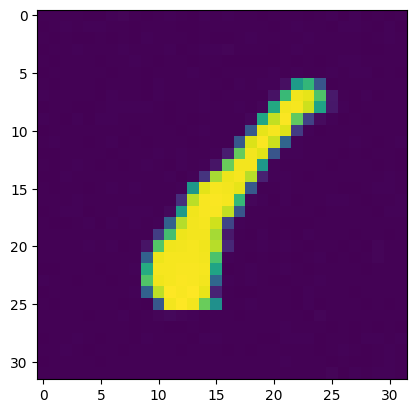

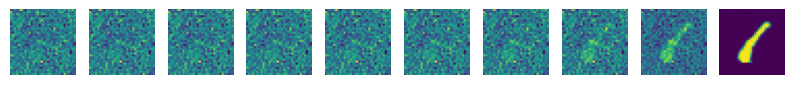

In [15]:
def main():
    # train(lr=2e-4, num_epochs=40, ema_decay=0.999)
    # DDPM sampling (1000 bước, stochastic)
    print(f"DDPM Sampling:")
    inference('/content/drive/MyDrive/genai/ddpm_checkpoint')
    # DDIM sampling (50 bước, deterministic) - nhanh hơn nhiều, dùng cùng checkpoint
    print(f"DDIM Sampling:")
    ddim_inference('/content/drive/MyDrive/genai/ddpm_checkpoint', ddim_steps=50, eta=0.0)

if __name__ == '__main__':
    main()